In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import re
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_rel, wilcoxon
import pandas as pd

In [5]:
dt_folder = Path(r"A:\processedData")
behaviorDataPaths = [f for f in dt_folder.rglob("*behavioralData_20msBins.pkl") if "ParadigmControls" not in str(f)]

rawDataset = dict()

for path in behaviorDataPaths:
    search = re.search(r"(\d+)_m(\d+)_obs(\d+)_behavioralData*", str(path))
    mouseID = search.group(2)
    obs = search.group(3)

    rawDataset.setdefault(mouseID, {})
    rawDataset[mouseID].setdefault(f"obs{obs}", {})

    with open(path,"rb") as f:
        behavioralData = pickle.load(f)

    rawDataset[mouseID][f"obs{obs}"]["behavioralData"] = behavioralData

    with open(next(path.parent.glob("*peripheralData_20msBins.pkl")),"rb") as f:
        peripheralData = pickle.load(f)

    rawDataset[mouseID][f"obs{obs}"]["peripheralData"] = peripheralData

dtFR = float(re.search(r"(\d+)msBins", path.name).group(1))/1000 #s
fs = 1/dtFR

tmin = 0.0
tmax = 1200
bins = np.arange(tmin,tmax,dtFR)

In [6]:
def compute_cross_correlation(stim, behavior, dtFR, max_lag_s=None):
    stim = np.asarray(stim, dtype=float)
    behavior = np.asarray(behavior, dtype=float)

    stim = (stim - stim.mean()) / (stim.std())
    behavior = (behavior - behavior.mean()) / (behavior.std())

    corr_full = np.correlate(behavior, stim, mode='full') / len(stim)

    n = len(stim)
    lags = np.arange(-n + 1, n) * dtFR

    if max_lag_s is not None:
        keep = np.abs(lags) <= max_lag_s
        lags = lags[keep]
        corr_full = corr_full[keep]

    return lags, corr_full

In [7]:
t_th = int(len(bins)/2)

nEvents_preAgg = 0
nEvents_postAgg = 0
nStim_preAgg = 0
nStim_postAgg = 0

for mouseID, obsData in rawDataset.items():
    for obs, data in obsData.items():

        if "ctBudSniff" not in data["behavioralData"]:
            continue 
        
        print(f"Processing mouse {mouseID}, {obs}...")

        rawDataset[mouseID][obs].setdefault("trialWiseCorr_Urine", {})

        TTL_postAgg = data["peripheralData"]["urineTTL"][t_th:]
        TTL_postAgg = (np.diff(TTL_postAgg, prepend=0) > 0).astype(float)
        nEvents_postAgg_session = np.sum(TTL_postAgg)
        nEvents_postAgg += nEvents_postAgg_session

        annotations_postAgg = data["behavioralData"]["ctBudSniff"][t_th:]
        nStim_postAgg_session = (np.diff(data["behavioralData"]["ctBudSniff"][t_th:], prepend=0) > 0).sum()
        nStim_postAgg += nStim_postAgg_session

        lags, perSessionCorr_postAgg = compute_cross_correlation(TTL_postAgg, annotations_postAgg, dtFR, 10)

        rawDataset[mouseID][obs]["trialWiseCorr_Urine"].setdefault("postAgg", {})
        rawDataset[mouseID][obs]["trialWiseCorr_Urine"]["postAgg"] = perSessionCorr_postAgg

        TTL_preAgg = data["peripheralData"]["urineTTL"][:t_th]
        TTL_preAgg = (np.diff(TTL_preAgg, prepend=0) > 0).astype(float)
        nEvents_preAgg_session = np.sum(TTL_preAgg)
        nEvents_preAgg += nEvents_preAgg_session

        annotations_preAgg = data["behavioralData"]["ctBudSniff"][:t_th]
        nStim_preAgg_session = (np.diff(data["behavioralData"]["ctBudSniff"][:t_th], prepend=0) > 0).sum()
        nStim_preAgg += nStim_preAgg_session

        _, perSessionCorr_preAgg = compute_cross_correlation(TTL_preAgg, annotations_preAgg, dtFR, 10)

        rawDataset[mouseID][obs]["trialWiseCorr_Urine"].setdefault("preAgg", {})
        rawDataset[mouseID][obs]["trialWiseCorr_Urine"]["preAgg"] = perSessionCorr_preAgg


Processing mouse 975826, obs1...
Processing mouse 975826, obs2...
Processing mouse 975826, obs3...
Processing mouse 975826, obs4...
Processing mouse 975826, obs5...
Processing mouse 975826, obs6...
Processing mouse 975827, obs1...
Processing mouse 975827, obs2...
Processing mouse 975827, obs3...
Processing mouse 975827, obs4...
Processing mouse 975830, obs1...
Processing mouse 975830, obs2...
Processing mouse 975830, obs3...
Processing mouse 975830, obs5...
Processing mouse 975833, obs1...
Processing mouse 975833, obs2...
Processing mouse 975833, obs3...
Processing mouse 975833, obs4...
Processing mouse 975833, obs5...
Processing mouse 975833, obs6...
Processing mouse 978772, obs1...
Processing mouse 978772, obs2...
Processing mouse 978772, obs3...
Processing mouse 978774, obs1...
Processing mouse 978774, obs2...
Processing mouse 978774, obs3...
Processing mouse 978775, obs1...
Processing mouse 978775, obs2...
Processing mouse 978775, obs3...
Processing mouse 988590, obs1...
Processing

C:\Users\Data Analysis\AppData\Local\Temp\ipykernel_5560\188683203.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Data Analysis\AppData\Local\Temp\ipykernel_5560\188683203.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


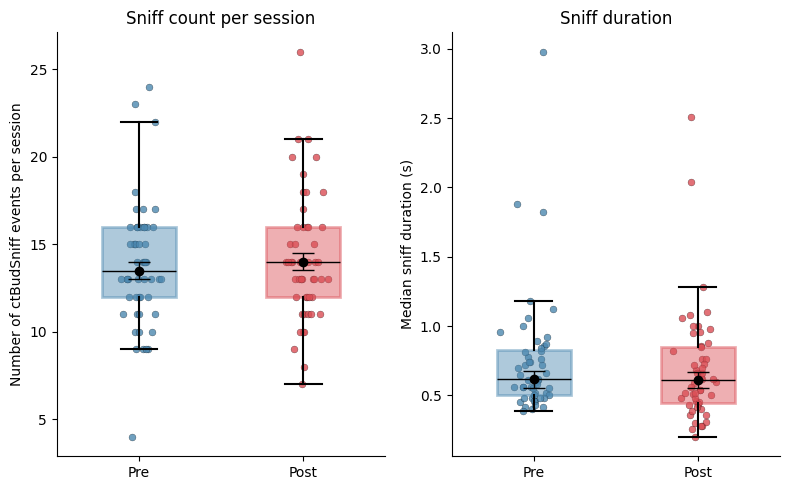

,mouseID,obs,period,n_events,median_high_duration_s,n_ttl_no_response,n_ttl_events
0,975826,obs1,preAgg,9,0.82,3,8
1,975826,obs1,postAgg,11,0.86,1,8
2,975826,obs2,preAgg,16,0.61,1,8
3,975826,obs2,postAgg,14,0.51,1,8
4,975826,obs3,preAgg,13,0.72,0,8
...,...,...,...,...,...,...,...
99,978513,obs6,postAgg,11,1.10,0,8
100,978527,obs6,preAgg,11,1.82,0,8
101,978527,obs6,postAgg,11,1.28,0,8
102,978528,obs6,preAgg,13,1.06,0,8


,median_events,median_high_duration_s,median_ttl_no_response,total_ttl_no_response,total_ttl_events
period,,,,,
postAgg,14.0,0.610,0.0,24,416
preAgg,13.5,0.615,0.0,19,416


In [18]:
# Color code
colors = {
    "preAgg": '#4C88B0',
    "postAgg": '#DB4E55'
}

rows = []

for mouseID, obsData in rawDataset.items():
    for obs, data in obsData.items():

        if "ctBudSniff" not in data["behavioralData"]:
            continue

        for period, sl in {
            "preAgg": slice(0, t_th),
            "postAgg": slice(t_th, None)
        }.items():

            beh = np.asarray(data["behavioralData"]["ctBudSniff"][sl]).astype(int)
            ttl = np.asarray(data["peripheralData"]["urineTTL"][sl]).astype(int)

            beh_onsets = np.where(np.diff(beh, prepend=0) > 0)[0]
            beh_offsets = np.where(np.diff(beh, append=0) < 0)[0] + 1
            beh_durations = (beh_offsets - beh_onsets) * dtFR

            ttl_onsets = np.where(np.diff(ttl, prepend=0) > 0)[0]
            ttl_offsets = np.where(np.diff(ttl, append=0) < 0)[0] + 1

            no_response = np.sum([
                np.sum(beh[s:e]) == 0
                for s, e in zip(ttl_onsets, ttl_offsets)
            ])

            rows.append({
                "mouseID": mouseID,
                "obs": obs,
                "period": period,
                "n_events": len(beh_onsets),
                "median_high_duration_s": np.nanmedian(beh_durations) if len(beh_durations) else np.nan,
                "n_ttl_no_response": no_response,
                "n_ttl_events": len(ttl_onsets)
            })

ctBudSniff_summary = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

plot_vars = [
    ("n_events", "Number of ctBudSniff events per session", "Sniff count per session"),
    ("median_high_duration_s", "Median sniff duration (s)", "Sniff duration"),
]

periods = ["preAgg", "postAgg"]
labels = ["Pre", "Post"]

for ax, (col, ylabel, title) in zip(axes, plot_vars):

    vals = [
        ctBudSniff_summary.loc[ctBudSniff_summary["period"] == p, col].dropna()
        for p in periods
    ]

    bp = ax.boxplot(
        vals,
        labels=labels,
        widths=0.45,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )

    for patch, period in zip(bp["boxes"], periods):
        patch.set_facecolor(colors[period])
        patch.set_alpha(0.45)
        patch.set_edgecolor(colors[period])
        patch.set_linewidth(2)

    for i, (y, period) in enumerate(zip(vals, periods), start=1):
        ax.scatter(
            np.random.normal(i, 0.055, len(y)),
            y,
            color=colors[period],
            alpha=0.8,
            s=25,
            edgecolor="black",
            linewidth=0.2
        )

        if len(y) > 0:
            med = np.nanmedian(y)
            sem = np.nanstd(y, ddof=1) / np.sqrt(len(y)) if len(y) > 1 else 0

            ax.errorbar(
                i,
                med,
                yerr=sem,
                fmt="o",
                color="black",
                capsize=8,
                markersize=6,
                linewidth=1
            )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

ctBudSniff_dataset_summary = ctBudSniff_summary.groupby("period").agg(
    median_events=("n_events", "median"),
    median_high_duration_s=("median_high_duration_s", "median"),
    median_ttl_no_response=("n_ttl_no_response", "median"),
    total_ttl_no_response=("n_ttl_no_response", "sum"),
    total_ttl_events=("n_ttl_events", "sum")
)

display(ctBudSniff_summary)
display(ctBudSniff_dataset_summary)

In [19]:
correlations = []

for mouseID, obsData in rawDataset.items():
    for obs, data in obsData.items():

        if "trialWiseCorr_Urine" not in data:
            continue
        
        for condition, corr in data["trialWiseCorr_Urine"].items():
            if condition == "preAgg":
                preCorr = corr
            elif condition == "postAgg":
                postCorr = corr
                
        correlations.append({"mouseID": mouseID,
                             "obs": obs,        
                             "pre_corr": preCorr,
                             "post_corr": postCorr})   

In [20]:
def peak_value(corr):
    return np.max(corr)

def peak_lag(corr, lags):
    return lags[np.argmax(corr)]

def auc_in_window(corr, lags, t0=0, t1=3.6):
    mask = (lags >= t0) & (lags <= t1)
    return np.trapezoid(corr[mask], x=lags[mask])

df = pd.DataFrame(correlations)   

df["pre_peak"] = df["pre_corr"].apply(peak_value)
df["post_peak"] = df["post_corr"].apply(peak_value)

df["pre_peak_lag"] = df["pre_corr"].apply(lambda x: peak_lag(x, lags))
df["post_peak_lag"] = df["post_corr"].apply(lambda x: peak_lag(x, lags))

df["pre_auc"] = df["pre_corr"].apply(lambda x: auc_in_window(x, lags, 0, 3.6))
df["post_auc"] = df["post_corr"].apply(lambda x: auc_in_window(x, lags, 0, 3.6))

In [21]:
mouse_df = df.groupby("mouseID").agg({
    "pre_peak": "mean",
    "post_peak": "mean",
    "pre_peak_lag": "mean",
    "post_peak_lag": "mean",
    "pre_auc": "mean",
    "post_auc": "mean"
}).reset_index()

print("n mice:", len(mouse_df))

print("Peak amplitude paired t-test:")
print(ttest_rel(mouse_df["pre_peak"], mouse_df["post_peak"]))

print("Peak amplitude Wilcoxon:")
print(wilcoxon(mouse_df["pre_peak"], mouse_df["post_peak"]))

print("Peak latency paired t-test:")
print(ttest_rel(mouse_df["pre_peak_lag"], mouse_df["post_peak_lag"]))

print("Peak latency Wilcoxon:")
print(wilcoxon(mouse_df["pre_peak_lag"], mouse_df["post_peak_lag"]))

print("AUC paired t-test:")
print(ttest_rel(mouse_df["pre_auc"], mouse_df["post_auc"]))

print("AUC Wilcoxon:")
print(wilcoxon(mouse_df["pre_auc"], mouse_df["post_auc"]))

n mice: 16
Peak amplitude paired t-test:
TtestResult(statistic=np.float64(-1.0626385072209077), pvalue=np.float64(0.3047553143610662), df=np.int64(15))
Peak amplitude Wilcoxon:
WilcoxonResult(statistic=np.float64(52.0), pvalue=np.float64(0.433197021484375))
Peak latency paired t-test:
TtestResult(statistic=np.float64(-0.3923735685136911), pvalue=np.float64(0.7003012367940917), df=np.int64(15))
Peak latency Wilcoxon:
WilcoxonResult(statistic=np.float64(63.0), pvalue=np.float64(0.820892333984375))
AUC paired t-test:
TtestResult(statistic=np.float64(4.188459798620217), pvalue=np.float64(0.0007911347181305056), df=np.int64(15))
AUC Wilcoxon:
WilcoxonResult(statistic=np.float64(8.0), pvalue=np.float64(0.000762939453125))


In [22]:
preAgg_corr = np.array(np.array([row["pre_corr"] for row in correlations]))
postAgg_corr = np.array(np.array([row["post_corr"] for row in correlations]))

averPreAgg = np.mean(preAgg_corr, axis=0)
averPostAgg = np.mean(postAgg_corr, axis=0)

stdPreAgg = np.std(preAgg_corr, axis=0)
stdPostAgg = np.std(postAgg_corr, axis=0)

C:\Users\Data Analysis\AppData\Local\Temp\ipykernel_5560\1836097246.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


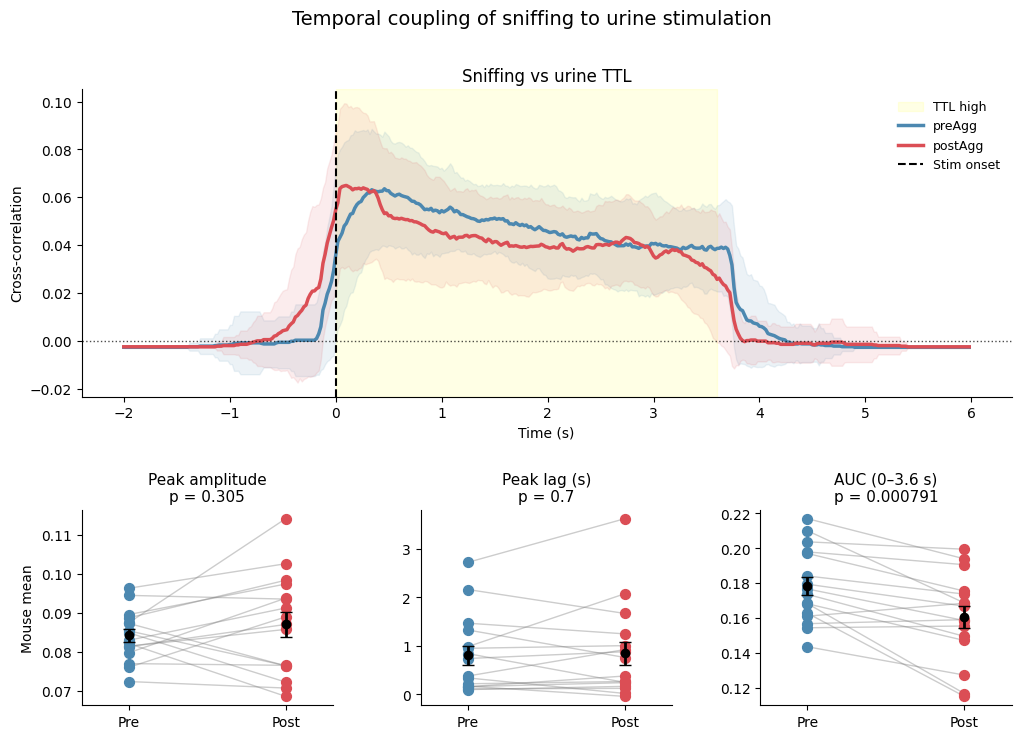

In [23]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[2.2, 1.4],
    hspace=0.45,
    wspace=0.35
)

# ==================================================
# Top panel: mean cross-correlation
# ==================================================
ax0 = fig.add_subplot(gs[0, :])

ax0.axvspan(0, 3.6, color='yellow', alpha=0.1, label='TTL high')

start = -2
stop = 6
s = np.argmin(np.abs(lags - start))
e = np.argmin(np.abs(lags - stop))

ax0.fill_between(
    lags[s:e],
    averPreAgg[s:e] - stdPreAgg[s:e],
    averPreAgg[s:e] + stdPreAgg[s:e],
    color="#4C88B0",
    alpha=0.1
)

ax0.fill_between(
    lags[s:e],
    averPostAgg[s:e] - stdPostAgg[s:e],
    averPostAgg[s:e] + stdPostAgg[s:e],
    color="#DB4E55",
    alpha=0.1
)

ax0.plot(
    lags[s:e],
    averPreAgg[s:e],
    label=f"preAgg",
    color="#4C88B0",
    linewidth=2.5
)

ax0.plot(
    lags[s:e],
    averPostAgg[s:e],
    label=f"postAgg",
    color="#DB4E55",
    linewidth=2.5
)

ax0.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Stim onset')
ax0.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.7)

ax0.set_xlabel("Time (s)")
ax0.set_ylabel("Cross-correlation")
ax0.set_title("Sniffing vs urine TTL")
ax0.legend(frameon=False, fontsize=9)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# ==================================================
# Bottom row: mouse-level stats
# ==================================================
metrics = [
    ("Peak amplitude", "pre_peak", "post_peak"),
    ("Peak lag (s)", "pre_peak_lag", "post_peak_lag"),
    ("AUC (0–3.6 s)", "pre_auc", "post_auc"),
]

axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

for ax, (title, pre_col, post_col) in zip(axes, metrics):
    pre = mouse_df[pre_col].values
    post = mouse_df[post_col].values

    for i in range(len(pre)):
        ax.plot([0, 1], [pre[i], post[i]], color='gray', alpha=0.4, linewidth=1)

    ax.scatter(np.zeros(len(pre)), pre, color='#4C88B0', s=50, zorder=3)
    ax.scatter(np.ones(len(post)), post, color='#DB4E55', s=50, zorder=3)

    mean_pre = np.mean(pre)
    mean_post = np.mean(post)
    sem_pre = np.std(pre, ddof=1) / np.sqrt(len(pre))
    sem_post = np.std(post, ddof=1) / np.sqrt(len(post))

    ax.errorbar(
        [0, 1],
        [mean_pre, mean_post],
        yerr=[sem_pre, sem_post],
        fmt='o',
        color='black',
        capsize=4,
        linewidth=2,
        markersize=6,
        zorder=4
    )

    _, p = ttest_rel(pre, post)

    ax.set_title(f"{title}\np = {p:.3g}", fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"])
    ax.set_xlim(-0.3, 1.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel("Mouse mean")

fig.suptitle("Temporal coupling of sniffing to urine stimulation", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

C:\Users\Data Analysis\AppData\Local\Temp\ipykernel_5560\3532010441.py:6: RuntimeWarning: invalid value encountered in divide
  behavior = (behavior - behavior.mean()) / (behavior.std())


n mice: 16


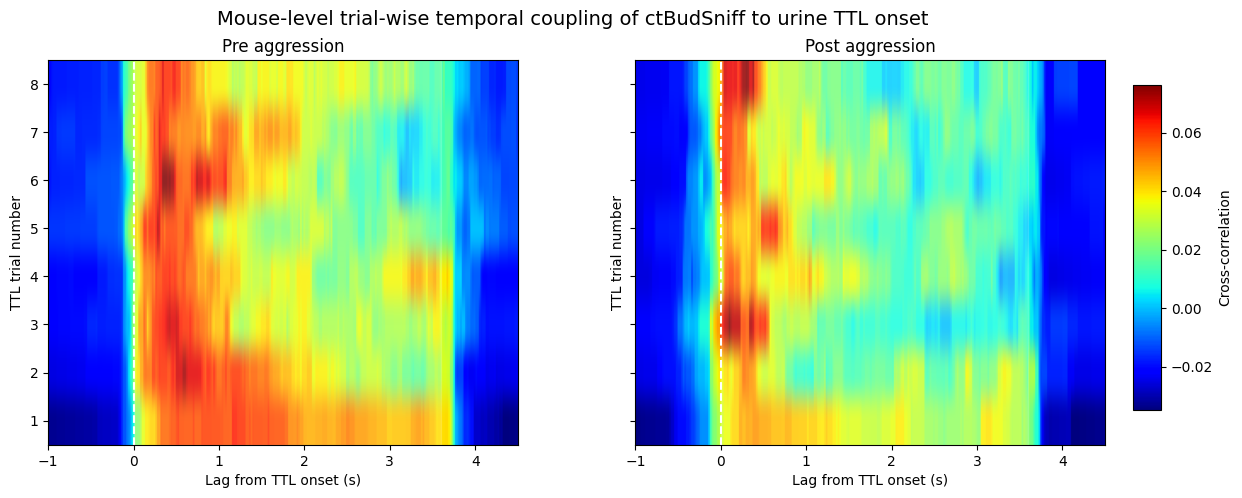

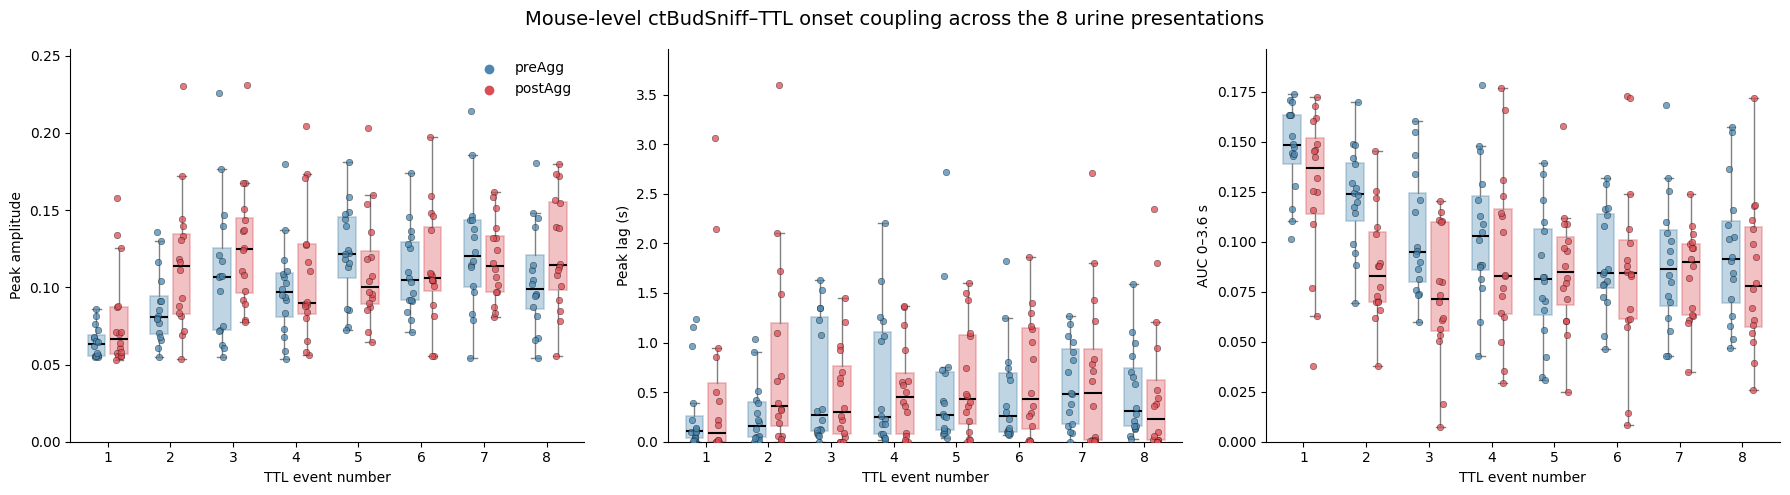

In [33]:
# ==================================================
# Build trial-wise correlations
# ==================================================
trial_corr_rows = []

for mouseID, obsData in rawDataset.items():
    for obs, data in obsData.items():

        if "ctBudSniff" not in data["behavioralData"]:
            continue

        for period, sl in {
            "preAgg": slice(0, t_th),
            "postAgg": slice(t_th, None)
        }.items():

            beh = np.asarray(data["behavioralData"]["ctBudSniff"][sl]).astype(int)
            ttl_raw = np.asarray(data["peripheralData"]["urineTTL"][sl]).astype(int)

            ttl_onset_signal = (np.diff(ttl_raw, prepend=0) > 0).astype(float)
            ttl_onsets = np.where(ttl_onset_signal > 0)[0]

            for trial_num, onset in enumerate(ttl_onsets[:8], start=1):

                win_start = max(0, onset - int(3 / dtFR))
                win_end = min(len(ttl_raw), onset + int(6 / dtFR))

                ttl_trial = ttl_onset_signal[win_start:win_end]
                beh_trial = beh[win_start:win_end]

                trial_lags, trial_corr = compute_cross_correlation(
                    ttl_trial,
                    beh_trial,
                    dtFR,
                    6
                )

                resp_mask = (trial_lags >= 0) & (trial_lags <= 3.6)
                resp_corr = trial_corr[resp_mask]
                resp_lags = trial_lags[resp_mask]

                if np.all(np.isnan(resp_corr)):
                    peak = np.nan
                    peak_lag = np.nan
                    auc = np.nan
                else:
                    peak = np.nanmax(resp_corr)
                    peak_lag = resp_lags[np.nanargmax(resp_corr)]
                    auc = auc_in_window(trial_corr, trial_lags, 0, 3.6)

                trial_corr_rows.append({
                    "mouseID": mouseID,
                    "obs": obs,
                    "period": period,
                    "trial_num": trial_num,
                    "corr": trial_corr,
                    "peak": peak,
                    "peak_lag": peak_lag,
                    "auc": auc
                })

trial_corr_df = pd.DataFrame(trial_corr_rows)


# ==================================================
# Mouse-level trial-wise correlations
# ==================================================
def nanmean_corr(corrs):
    valid = [c for c in corrs if np.any(~np.isnan(c))]
    if len(valid) == 0:
        return np.full_like(trial_lags, np.nan, dtype=float)
    return np.nanmean(np.vstack(valid), axis=0)


mouse_trial_corr_df = (
    trial_corr_df
    .groupby(["mouseID", "period", "trial_num"])
    .agg(
        corr=("corr", nanmean_corr),
        peak=("peak", "mean"),
        peak_lag=("peak_lag", "mean"),
        auc=("auc", "mean")
    )
    .reset_index()
)

print("n mice:", mouse_trial_corr_df["mouseID"].nunique())


# ==================================================
# Mouse-level trial-wise average correlation heatmaps
# ==================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

x0, x1 = -1, 4.5

for ax, period, title in zip(
    axes,
    ["preAgg", "postAgg"],
    ["Pre aggression", "Post aggression"]
):

    heat = []

    for trial_num in range(1, 9):
        trial_corrs = mouse_trial_corr_df.loc[
            (mouse_trial_corr_df["period"] == period) &
            (mouse_trial_corr_df["trial_num"] == trial_num),
            "corr"
        ]

        valid_corrs = [c for c in trial_corrs if np.any(~np.isnan(c))]

        if len(valid_corrs) > 0:
            heat.append(np.nanmean(np.vstack(valid_corrs), axis=0))
        else:
            heat.append(np.full_like(trial_lags, np.nan, dtype=float))

    heat = np.vstack(heat)

    x_mask = (trial_lags >= x0) & (trial_lags <= x1)
    heat_plot = heat[:, x_mask]
    lags_plot = trial_lags[x_mask]

    im = ax.imshow(
        heat_plot,
        aspect="auto",
        origin="lower",
        extent=[lags_plot[0], lags_plot[-1], 0.5, 8.5],
        cmap="jet"
    )

    ax.axvline(0, color="white", linestyle="--", linewidth=1.5)
    ax.axvspan(0, 3.6, color="white", alpha=0.15)

    ax.set_xlim(x0, x1)
    ax.set_title(title)
    ax.set_xlabel("Lag from TTL onset (s)")
    ax.set_ylabel("TTL trial number")
    ax.set_yticks(range(1, 9))

fig.subplots_adjust(right=0.88, wspace=0.25)
cbar_ax = fig.add_axes([0.90, 0.18, 0.02, 0.65])
fig.colorbar(im, cax=cbar_ax, label="Cross-correlation")

fig.suptitle(
    "Mouse-level trial-wise temporal coupling of ctBudSniff to urine TTL onset",
    fontsize=14
)

plt.show()


# ==================================================
# Mouse-level trial-wise metric box plots
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("peak", "Peak amplitude"),
    ("peak_lag", "Peak lag (s)"),
    ("auc", "AUC 0–3.6 s")
]

colors = {
    "preAgg": "#4C88B0",
    "postAgg": "#DB4E55"
}

offset = 0.18
box_width = 0.28
jitter_width = 0.045

for ax, (metric, ylabel) in zip(axes, metrics):

    box_data = []
    positions = []
    box_colors = []

    for trial_num in range(1, 9):

        pre_vals = mouse_trial_corr_df.loc[
            (mouse_trial_corr_df["period"] == "preAgg") &
            (mouse_trial_corr_df["trial_num"] == trial_num),
            metric
        ].dropna().values

        post_vals = mouse_trial_corr_df.loc[
            (mouse_trial_corr_df["period"] == "postAgg") &
            (mouse_trial_corr_df["trial_num"] == trial_num),
            metric
        ].dropna().values

        box_data.extend([pre_vals, post_vals])
        positions.extend([trial_num - offset, trial_num + offset])
        box_colors.extend([colors["preAgg"], colors["postAgg"]])

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.2)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    for whisker in bp["whiskers"]:
        whisker.set_color("gray")
        whisker.set_linewidth(1)

    for cap in bp["caps"]:
        cap.set_color("gray")
        cap.set_linewidth(1)

    # Overlay jittered individual mouse points
    for trial_num in range(1, 9):

        for period, x_center in [
            ("preAgg", trial_num - offset),
            ("postAgg", trial_num + offset)
        ]:

            vals = mouse_trial_corr_df.loc[
                (mouse_trial_corr_df["period"] == period) &
                (mouse_trial_corr_df["trial_num"] == trial_num),
                metric
            ].dropna().values

            jitter = np.random.uniform(
                -jitter_width,
                jitter_width,
                size=len(vals)
            )

            ax.scatter(
                np.full(len(vals), x_center) + jitter,
                vals,
                color=colors[period],
                s=22,
                alpha=0.75,
                edgecolor="black",
                linewidth=0.3,
                zorder=3
            )

    # Force x-axis labels to be 1–8 only
    ax.set_xticks(range(1, 9))
    ax.set_xticklabels([str(i) for i in range(1, 9)])

    # Set y-axis from 0 to max value for this metric
    metric_max = mouse_trial_corr_df[metric].max(skipna=True)
    ax.set_ylim(0, metric_max * 1.1)

    ax.set_xlabel("TTL event number")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0.4, 8.6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend
axes[0].scatter([], [], color=colors["preAgg"], label="preAgg")
axes[0].scatter([], [], color=colors["postAgg"], label="postAgg")
axes[0].legend(frameon=False)

fig.suptitle(
    "Mouse-level ctBudSniff–TTL onset coupling across the 8 urine presentations",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [35]:
import statsmodels.formula.api as smf
# =========================================================
# Observation-level longitudinal analysis from existing df
# Requires existing:
#   - df
#   - columns already present in df:
#       pre_peak, post_peak, pre_peak_lag, post_peak_lag, pre_auc, post_auc
# =========================================================

stats_df = pd.concat([
    df[["mouseID", "obs", "pre_peak", "pre_peak_lag", "pre_auc"]]
      .rename(columns={
          "pre_peak": "peak",
          "pre_peak_lag": "peak_lag",
          "pre_auc": "auc"
      })
      .assign(condition="preAgg"),

    df[["mouseID", "obs", "post_peak", "post_peak_lag", "post_auc"]]
      .rename(columns={
          "post_peak": "peak",
          "post_peak_lag": "peak_lag",
          "post_auc": "auc"
      })
      .assign(condition="postAgg")
], ignore_index=True)

stats_df["mouseID"] = stats_df["mouseID"].astype(str)
stats_df["obs"] = (
    stats_df["obs"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)
stats_df["condition"] = pd.Categorical(
    stats_df["condition"],
    categories=["preAgg", "postAgg"]
)

display(stats_df.head())

metrics = ["auc", "peak", "peak_lag"]
model_results = {}

for metric in metrics:
    model = smf.mixedlm(
        f"{metric} ~ condition * obs",
        data=stats_df,
        groups=stats_df["mouseID"]
    )
    result = model.fit()
    model_results[metric] = result

    print(f"\n{'='*18} {metric.upper()} MODEL {'='*18}")
    print(result.summary())

summary = (
    stats_df.groupby(["obs", "condition"])
    .agg(
        mean_auc=("auc", "mean"),
        sem_auc=("auc", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
        mean_peak=("peak", "mean"),
        sem_peak=("peak", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
        mean_lag=("peak_lag", "mean"),
        sem_lag=("peak_lag", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
        n_sessions=("mouseID", "size"),
        n_mice=("mouseID", pd.Series.nunique)
    )
    .reset_index()
)

display(summary)

,mouseID,obs,peak,peak_lag,auc,condition
0,975826,1,0.088945,0.46,0.113875,preAgg
1,975826,2,0.072520,1.00,0.183670,preAgg
2,975826,3,0.092918,-0.72,0.119433,preAgg
3,975826,4,0.090958,0.00,0.189634,preAgg
4,975826,5,0.096582,0.04,0.176919,preAgg


c:\Users\Data Analysis\anaconda3\envs\decoding\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\Data Analysis\anaconda3\envs\decoding\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



================== AUC MODEL ==================
               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     auc     
No. Observations:      104         Method:                 REML    
No. Groups:            16          Scale:                  0.0007  
Min. group size:       2           Log-Likelihood:         203.9836
Max. group size:       12          Converged:              Yes     
Mean group size:       6.5                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.172    0.009 18.869 0.000  0.154  0.190
condition[T.postAgg]     -0.026    0.011 -2.473 0.013 -0.047 -0.005
obs                       0.001    0.002  0.397 0.691 -0.004  0.006
condition[T.postAgg]:obs  0.004    0.003  1.107 0.268 -0.003  0.010
Group Var     

,obs,condition,mean_auc,sem_auc,mean_peak,sem_peak,mean_lag,sem_lag,n_sessions,n_mice
0,1,preAgg,0.172819,0.008485,0.092127,0.003513,0.640000,0.167699,13,13
1,1,postAgg,0.145119,0.010804,0.089546,0.007310,0.610769,0.291878,13,13
2,2,preAgg,0.165609,0.006884,0.084908,0.004846,0.478000,0.187343,10,10
3,2,postAgg,0.155304,0.008996,0.087498,0.005029,0.922000,0.368184,10,10
4,3,preAgg,0.175148,0.007899,0.082134,0.003500,0.576923,0.243635,13,13
5,3,postAgg,0.156477,0.010981,0.088107,0.005375,0.536923,0.235163,13,13
6,4,preAgg,0.169530,0.015004,0.076936,0.008271,1.146667,0.676100,6,6
7,4,postAgg,0.159090,0.013689,0.083948,0.007844,1.216667,0.529639,6,6
8,5,preAgg,0.172704,0.005767,0.092238,0.003443,0.405000,0.391780,4,4
9,5,postAgg,0.173208,0.009145,0.085398,0.006197,0.060000,0.029439,4,4


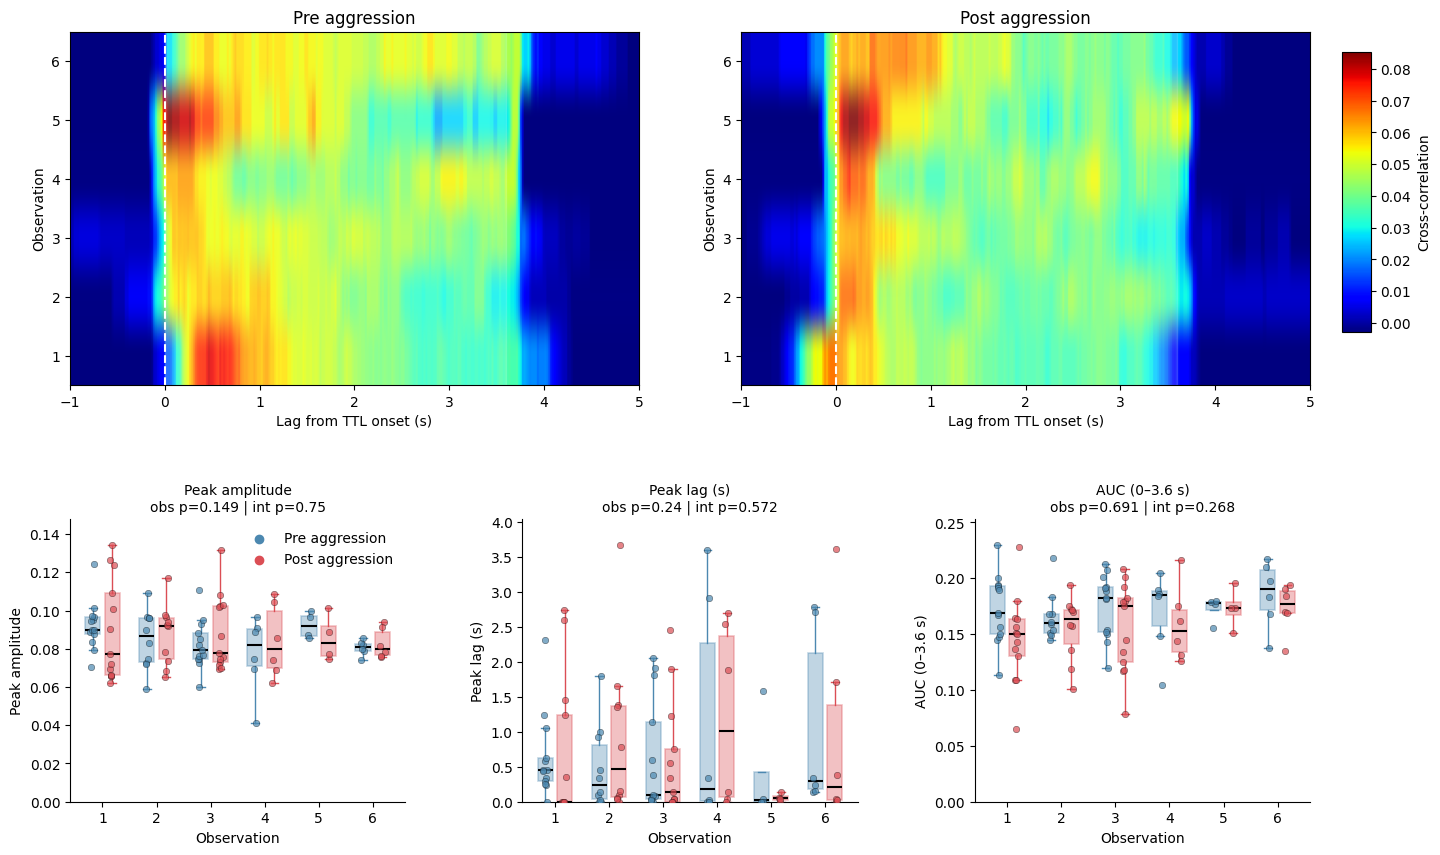

In [39]:
# =========================================================
# Observation-wise heatmaps + observation-wise longitudinal plots
# Requires existing:
#   df, summary, model_results, lags
# =========================================================

colors = {
    "preAgg": "#4C88B0",
    "postAgg": "#DB4E55"
}

labels = {
    "preAgg": "Pre aggression",
    "postAgg": "Post aggression"
}

x0, x1 = -1, 5
x_mask = (lags >= x0) & (lags <= x1)
lags_plot = lags[x_mask]

obs_numeric = (
    df["obs"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)

df_obs = df.copy()
df_obs["obs_num"] = obs_numeric

obs_order = np.sort(df_obs["obs_num"].unique())


# =========================================================
# Mouse-level average per observation
# =========================================================
def nanmean_corr(corrs):
    valid = [c for c in corrs if np.any(~np.isnan(c))]
    if len(valid) == 0:
        return np.full_like(lags, np.nan, dtype=float)
    return np.nanmean(np.vstack(valid), axis=0)


obs_mouse_df = (
    df_obs
    .groupby(["mouseID", "obs_num"])
    .agg(
        pre_corr=("pre_corr", nanmean_corr),
        post_corr=("post_corr", nanmean_corr),
        pre_peak=("pre_peak", "mean"),
        post_peak=("post_peak", "mean"),
        pre_peak_lag=("pre_peak_lag", "mean"),
        post_peak_lag=("post_peak_lag", "mean"),
        pre_auc=("pre_auc", "mean"),
        post_auc=("post_auc", "mean")
    )
    .reset_index()
)


# =========================================================
# Figure layout
# =========================================================
fig = plt.figure(figsize=(16, 10))

outer = fig.add_gridspec(
    2, 1,
    height_ratios=[1.25, 1],
    hspace=0.42
)

top_gs = outer[0].subgridspec(1, 2, wspace=0.18)
bottom_gs = outer[1].subgridspec(1, 3, wspace=0.35)

heat_axes = [
    fig.add_subplot(top_gs[0, 0]),
    fig.add_subplot(top_gs[0, 1])
]

plot_axes = [
    fig.add_subplot(bottom_gs[0, 0]),
    fig.add_subplot(bottom_gs[0, 1]),
    fig.add_subplot(bottom_gs[0, 2])
]


# =========================================================
# Top row: observation-wise mouse-level heatmaps
# =========================================================
heat_specs = [
    ("preAgg", "pre_corr", "Pre aggression"),
    ("postAgg", "post_corr", "Post aggression")
]

im = None

for ax, (condition, corr_col, title) in zip(heat_axes, heat_specs):

    heat = []

    for obs_num in obs_order:

        obs_corrs = obs_mouse_df.loc[
            obs_mouse_df["obs_num"] == obs_num,
            corr_col
        ]

        valid_corrs = [
            c for c in obs_corrs
            if np.any(~np.isnan(c))
        ]

        if len(valid_corrs) > 0:
            mean_corr = np.nanmean(np.vstack(valid_corrs), axis=0)
            heat.append(mean_corr[x_mask])
        else:
            heat.append(np.full_like(lags_plot, np.nan, dtype=float))

    heat = np.vstack(heat)

    im = ax.imshow(
        heat,
        aspect="auto",
        origin="lower",
        extent=[
            lags_plot[0],
            lags_plot[-1],
            obs_order[0] - 0.5,
            obs_order[-1] + 0.5
        ],
        cmap="jet"
    )

    ax.axvline(0, color="white", linestyle="--", linewidth=1.5)
    ax.axvspan(0, 3.6, color="white", alpha=0.15)

    ax.set_xlim(x0, x1)
    ax.set_title(title)
    ax.set_xlabel("Lag from TTL onset (s)")
    ax.set_ylabel("Observation")
    ax.set_yticks(obs_order)

fig.subplots_adjust(right=0.90)

cbar_ax = fig.add_axes([0.92, 0.58, 0.018, 0.28])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Cross-correlation")


# =========================================================
# Bottom row: observation-wise box plots
# =========================================================
plot_specs = [
    ("peak", "Peak amplitude", "peak"),
    ("peak_lag", "Peak lag (s)", "peak_lag"),
    ("auc", "AUC (0–3.6 s)", "auc")
]

offset = 0.18
box_width = 0.28
jitter_width = 0.045

for ax, (metric, ylab, metric_key) in zip(plot_axes, plot_specs):

    for condition, sign in zip(["preAgg", "postAgg"], [-1, 1]):

        data = []
        positions = []

        for obs_num in obs_order:

            vals = stats_df.loc[
                (stats_df["condition"] == condition) &
                (stats_df["obs"] == obs_num),
                metric
            ].dropna().values

            data.append(vals)
            positions.append(obs_num + sign * offset)

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=box_width,
            patch_artist=True,
            showfliers=False
        )

        for box in bp["boxes"]:
            box.set_facecolor(colors[condition])
            box.set_alpha(0.35)
            box.set_edgecolor(colors[condition])
            box.set_linewidth(1.2)

        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        for whisker in bp["whiskers"]:
            whisker.set_color(colors[condition])

        for cap in bp["caps"]:
            cap.set_color(colors[condition])

        # Jittered individual points
        for obs_num, vals in zip(obs_order, data):

            jitter = np.random.uniform(
                -jitter_width,
                jitter_width,
                size=len(vals)
            )

            ax.scatter(
                np.full(len(vals), obs_num + sign * offset) + jitter,
                vals,
                color=colors[condition],
                s=22,
                alpha=0.7,
                edgecolor="black",
                linewidth=0.3,
                zorder=3
            )

    p_obs = model_results[metric_key].pvalues.get("obs", np.nan)
    p_int = model_results[metric_key].pvalues.get(
        "condition[T.postAgg]:obs",
        np.nan
    )

    ax.set_title(
        f"{ylab}\nobs p={p_obs:.3g} | int p={p_int:.3g}",
        fontsize=10
    )

    ax.set_xlabel("Observation")
    ax.set_ylabel(ylab)
    ax.set_xticks(obs_order)
    ax.set_xticklabels([str(o) for o in obs_order])
    ax.set_xlim(obs_order[0] - 0.6, obs_order[-1] + 0.6)

    metric_max = stats_df[metric].max(skipna=True)
    ax.set_ylim(0, metric_max * 1.1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_axes[0].scatter([], [], color=colors["preAgg"], label=labels["preAgg"])
plot_axes[0].scatter([], [], color=colors["postAgg"], label=labels["postAgg"])
plot_axes[0].legend(frameon=False)